In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
data_path = os.path.join(project_root, "data", "processed", "cleaned_ecommerce_data.csv")

df = pd.read_csv(data_path)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Данные успешно загружены для RFM-анализа. Строк: {df.shape[0]}")

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': lambda x: x.nunique(),
    'TotalPrice': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm = rfm[rfm['Monetary'] > 0]

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if r >= 4 and f >= 4:
        return 'Champions (Постоянные и преданные)'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers (Лояльные)'
    elif r >= 4 and f < 3:
        return 'New Customers (Новички)'
    elif r < 3 and f >= 3:
        return 'At Risk (В зоне риска — засыпают)'
    else:
        return 'Hibernating (Ушедшие / Спящие)'

rfm['Segment_Name'] = rfm.apply(assign_segment, axis=1)

print("\n=== РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО БИЗНЕС-СЕГМЕНТАМ ===")
segment_counts = rfm['Segment_Name'].value_counts()
for seg, count in segment_counts.items():
    print(f"Сегмент '{seg}': {count} клиентов")

Данные успешно загружены для RFM-анализа. Строк: 401564

=== РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО БИЗНЕС-СЕГМЕНТАМ ===
Сегмент 'Hibernating (Ушедшие / Спящие)': 1406 клиентов
Сегмент 'Champions (Постоянные и преданные)': 1116 клиентов
Сегмент 'Loyal Customers (Лояльные)': 796 клиентов
Сегмент 'At Risk (В зоне риска — засыпают)': 680 клиентов
Сегмент 'New Customers (Новички)': 323 клиентов


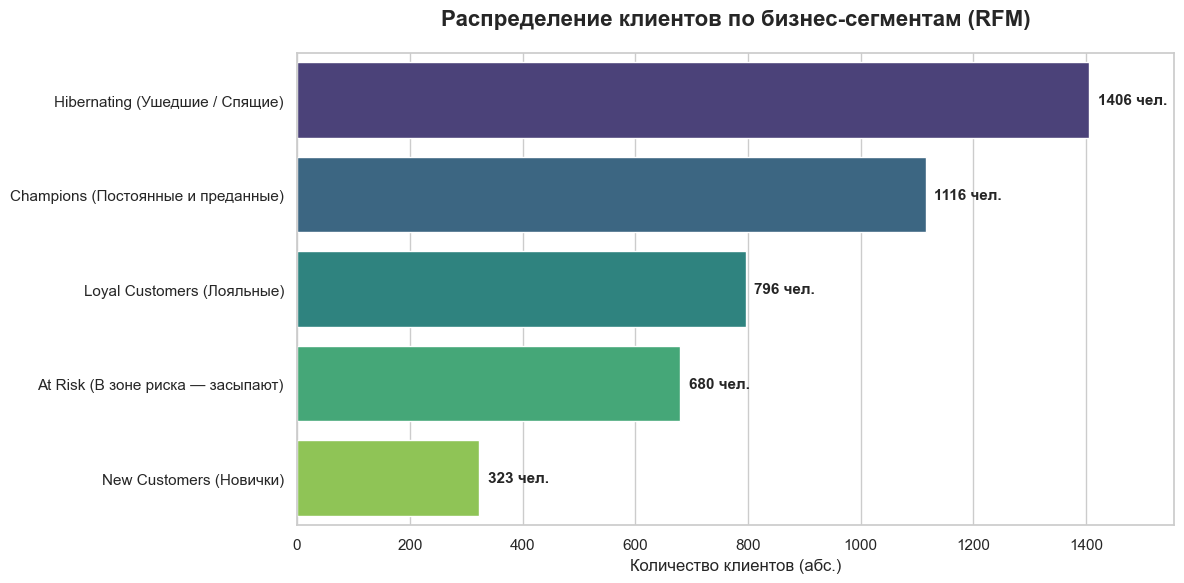


 СВОДНЫЙ АНАЛИЗ МЕТРИК СЕГМЕНТОВ 


,Segment_Name,Recency,Frequency,Monetary,Customer_Count
2,Hibernating (Ушедшие / Спящие),170.7,1.2,408.6,1406
1,Champions (Постоянные и преданные),12.0,12.2,5090.9,1116
3,Loyal Customers (Лояльные),35.3,4.5,1436.5,796
0,At Risk (В зоне риска — засыпают),152.0,4.0,1112.2,680
4,New Customers (Новички),17.1,1.4,421.0,323


In [7]:
segment_analysis = rfm.groupby('Segment_Name').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Segment': 'count'
}).rename(columns={'RFM_Segment': 'Customer_Count'}).reset_index()

segment_analysis = segment_analysis.sort_values(by='Customer_Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Customer_Count',
    y='Segment_Name',
    data=segment_analysis,
    palette='viridis',
    hue='Segment_Name',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 15,
            p.get_y() + p.get_height() / 2,
            f'{int(width)} чел.',
            ha='left',
            va='center',
            fontsize=11,
            fontweight='bold'
        )

plt.title('Распределение клиентов по бизнес-сегментам (RFM)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Количество клиентов (абс.)', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xlim(0, segment_analysis['Customer_Count'].max() + 150)

plt.tight_layout()
plt.show()

print("\n СВОДНЫЙ АНАЛИЗ МЕТРИК СЕГМЕНТОВ ")
display(segment_analysis.round(1))